# Import modules

In [1]:
import numpy as np
import pandas as pd
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.nquality import QualityBuilder
import matplotlib.pyplot as plt
from pipedream_solver.simulation import Simulation
from pipedream_solver.diagnostics import PerformanceTracker
import seaborn as sns


# Read input data

In [2]:
input_path = '../data/a2_wq'
superjunctions = pd.read_csv(f'{input_path}/superjunctions.csv')
superlinks = pd.read_csv(f'{input_path}/superlinks.csv')
superlink_wq_params = pd.read_csv(f'{input_path}/superlink_wq_params.csv')
superjunction_wq_params = pd.read_csv(f'{input_path}/superjunction_wq_params.csv')
orifices = pd.read_csv(f'{input_path}/orifices.csv')

# Load comparison data
Data_swmm_depth = pd.read_csv(f'{input_path}/Data_swmm_depth.csv')
Data_swmm_flow = pd.read_csv(f'{input_path}/Data_swmm_flow.csv')
Data_swmm_tss = pd.read_csv(f'{input_path}/Data_swmm_tss.csv')


In [3]:
superjunctions['c'] = np.maximum(superjunctions['c'], 1.16)
superjunctions['h_0'] = 1e-3
superlinks['h_0'] = 1e-3

# Instantiate model

In [4]:
dt = 5
internal_links = 60
num_iter = 40
spinup_steps = 10

superlink = SuperLink(superlinks, superjunctions, orifices=orifices,
                      internal_links=internal_links, mobile_elements=False)
waterquality = QualityBuilder(superlink, 
                              superjunction_params=superjunction_wq_params,
                              superlink_params=superlink_wq_params)

# Spin up model
superlink.spinup(n_steps=spinup_steps)

# Initialize volume for mass balance tracking
superlink.volume_tracker.set_init_volume()

# Add run-time performance tracker
performance_tracker = PerformanceTracker(superlink)
superlink.bind_callback(performance_tracker, 'performance_tracker')
superlink.performance_tracker = performance_tracker

# Set parameters for Newton iterations
superlink.convergence_tracker.max_learning_rate = 1.
superlink.convergence_tracker.beta = 2.
superlink.convergence_tracker.xtol = 1e-3
superlink.convergence_tracker.min_learning_rate = 0.05


# Plot model layout

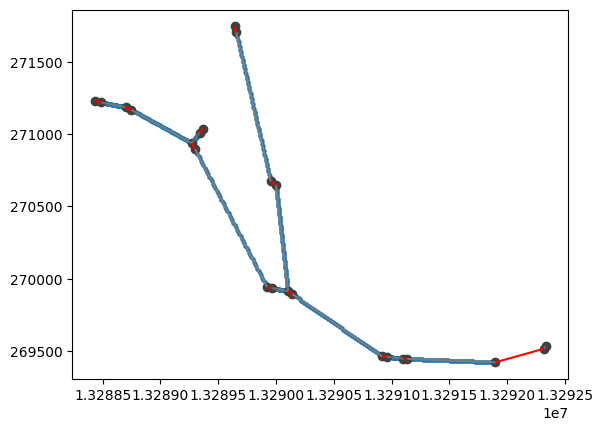

In [5]:
# Visualize network structure
fig, ax = plt.subplots()
_ = superlink.plot_network_2d(ax=ax, junction_kwargs={'s' : 5},
                              superjunction_kwargs={'c' : '0.25'},
                              link_kwargs={'color' : '0.5'},
                              orifice_kwargs={'color' : 'r'})


## Prepare inputs

In [6]:
# Add a small amount of lateral inflow for conditioning
Q_0Ik = 1e-6 * np.ones(superlink.NIk)

# Kalman Filter variables and data
x_hats = []
measure = pd.read_csv(f'{input_path}/measurement_input.csv')
measure = pd.DataFrame(measure).to_numpy()

# Scenario names of the base and 10 disturbed input timeseries of contaminant concentration
scenario_list = ['Base']

# Load the input wq data of scenarios
wq_in_data = {}
wq_input_file_prefix_ = 'N_Data_conc_input_'
for i in range(0,len(scenario_list)):
    wq_in_data[scenario_list[i]] = pd.read_csv(f'{input_path}/{wq_input_file_prefix_+scenario_list[i]}.csv', index_col=0)
    wq_in_data[scenario_list[i]] = pd.DataFrame(wq_in_data[scenario_list[i]]).to_numpy()

# Load forcing data
Q_in_file = pd.read_csv(f'{input_path}/N_Data_flow_input.csv', index_col=0)

# Create "open" control signal for orifices
u = np.ones(len(orifices))


## Run simulation

In [7]:
# Create dictionaries to store diagnostic information
iterations_elapsed = {}
convergence_queues = {}
learning_queues = {}
error_queues = {}
decrement_queues = {}
volume_in_system = {}
volume_net_added = {}
step_time_taken = {}

In [8]:
# Model only simulation for 11 different scenarios
c_j_model_only = {}
C_in = wq_in_data['Base']
t_end = Q_in_file.index[-1]
T = 0
c_j_temp = []
with Simulation(superlink, dt=dt, t_end=t_end, interpolation_method='linear') as simulation:
    Num_T = int(simulation.t_end/dt)+1
    Estimated_out = np.zeros(Num_T)
    Original_out = np.zeros(Num_T)
    Observed_out = np.zeros(Num_T)

    while superlink.t < t_end:
        c_0j = C_in[T,:]
        c_0j = np.array(c_0j)
        Q_in = Q_in_file.iloc[T][:]
        Q_in = np.array(Q_in)

        # Advance hydraulic model
        simulation.step(dt=dt, u_o=u, Q_in=Q_in, num_iter=num_iter, Q_Ik=Q_0Ik)

        # Advance water quality model
        waterquality.step(dt=dt, c_0j=c_0j)

        # Record nodal contaminant concentrations
        c_j_temp.append(waterquality.c_j.copy())
        
        simulation.record_state()
        simulation.print_progress()
        T += 1
        iterations_elapsed[simulation.t] = superlink.iter_elapsed
        convergence_queues[simulation.t] = superlink.convergence_tracker.convergence_queue
        error_queues[simulation.t] = superlink.convergence_tracker.error_queue
        decrement_queues[simulation.t] = superlink.convergence_tracker.decrement_queue
        learning_queues[simulation.t] = superlink.convergence_tracker.learning_queue
        volume_in_system[simulation.t] = superlink.volume_tracker.total_volume
        volume_net_added[simulation.t] = superlink.volume_tracker.cumulative_volume_flux
        step_time_taken[simulation.t] = superlink.performance_tracker.step_time_elapsed
        if superlink.iter_elapsed >= num_iter:
            raise ValueError
    c_j_model_only['Base'] = c_j_temp
    #print(f'\n▶▶▶▶▶ [Model only] Scenario "{scenario_}" is finished.')


[=================================================-] 98.0% [99.32 s]

# Plot time series of states

In [9]:
model = superlink
h_j = (simulation.states.H_j - simulation.states.H_j.iloc[0])

<Figure size 640x480 with 0 Axes>

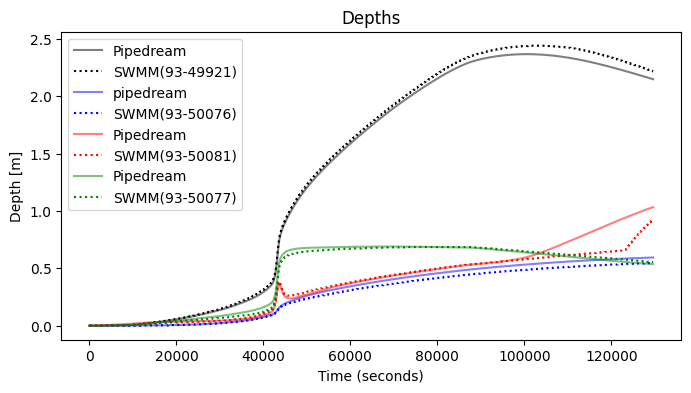

In [10]:
## Fig.14 in the paper: TSS output
#c_j2 = np.array(c_j_model_only['Base'])
plt.figure(2)
plt.figure(figsize= (8,4))
x_axis_ = np.linspace(dt,dt*len(h_j),len(h_j))
plt.plot(x_axis_, h_j['93-49921'], label = 'Pipedream', color = 'black', alpha = 0.5)
plt.plot(x_axis_, 0.3048 * Data_swmm_depth[['93-49921']], ":", label = 'SWMM(93-49921)', color = 'black')
plt.plot(x_axis_, h_j['93-50076'], label = 'pipedream', color = 'b', alpha = 0.5)
plt.plot(x_axis_, 0.3048 * Data_swmm_depth[['93-50076']], ":", label = 'SWMM(93-50076)', color = 'b')
plt.plot(x_axis_, h_j['93-50081'], label = 'Pipedream', color = 'r', alpha = 0.5)
plt.plot(x_axis_, 0.3048 * Data_swmm_depth[['93-50081']],":", label = 'SWMM(93-50081)', color = 'r')
plt.plot(x_axis_, h_j['93-50077'], label = 'Pipedream', color = 'g', alpha = 0.5)
plt.plot(x_axis_, 0.3048 * Data_swmm_depth[['93-50077']],":", label = 'SWMM(93-50077)', color = 'g')
plt.title('Depths')
plt.ylabel('Depth [m]')
plt.xlabel('Time (seconds)')
plt.legend()

<Figure size 640x480 with 0 Axes>

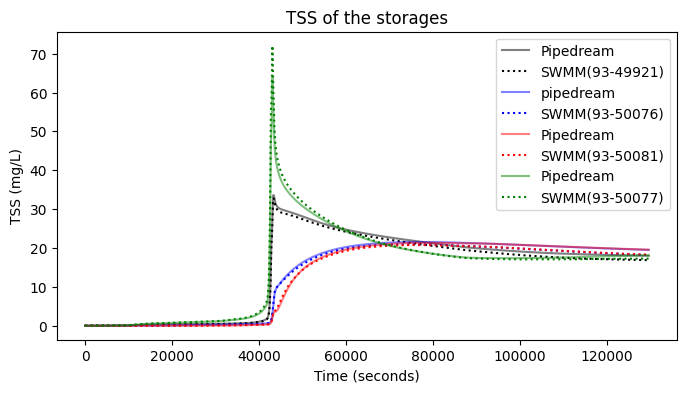

In [11]:

## Fig.14 in the paper: TSS output
c_j2 = np.array(c_j_model_only['Base'])
plt.figure(2)
plt.figure(figsize= (8,4))
x_axis_ = np.linspace(dt,dt*len(h_j),len(h_j))
plt.plot(x_axis_[0:-1],c_j2[:,3], label = 'Pipedream', color = 'black', alpha = 0.5)
plt.plot(x_axis_,Data_swmm_tss[['93-49921']], ":", label = 'SWMM(93-49921)', color = 'black')
plt.plot(x_axis_[0:-1],c_j2[:,5], label = 'pipedream', color = 'b', alpha = 0.5)
plt.plot(x_axis_,Data_swmm_tss[['93-50076']], ":", label = 'SWMM(93-50076)', color = 'b')
plt.plot(x_axis_[0:-1],c_j2[:,7], label = 'Pipedream', color = 'r', alpha = 0.5)
plt.plot(x_axis_,Data_swmm_tss[['93-50081']],":", label = 'SWMM(93-50081)', color = 'r')
plt.plot(x_axis_[0:-1],c_j2[:,6], label = 'Pipedream', color = 'g', alpha = 0.5)
plt.plot(x_axis_,Data_swmm_tss[['93-50077']],":", label = 'SWMM(93-50077)', color = 'g')
plt.title('TSS of the storages')
plt.ylabel('TSS (mg/L)')
#plt.ylim(0,80)
plt.xlabel('Time (seconds)')
plt.legend()

# Mass balance analysis

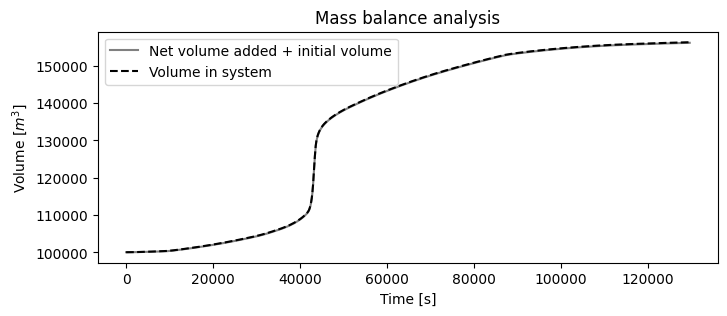

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
(pd.Series(volume_net_added) + model.volume_tracker.init_volume).plot(ax=ax, label='Net volume added + initial volume', c='0.5')
pd.Series(volume_in_system).plot(ax=ax, label='Volume in system', c='k', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Volume [$m^3$]')
plt.title('Mass balance analysis')
_ = plt.legend()

# Convergence analysis

### Step convergence criterion $||x_{new} - x_{old}||_\infty$

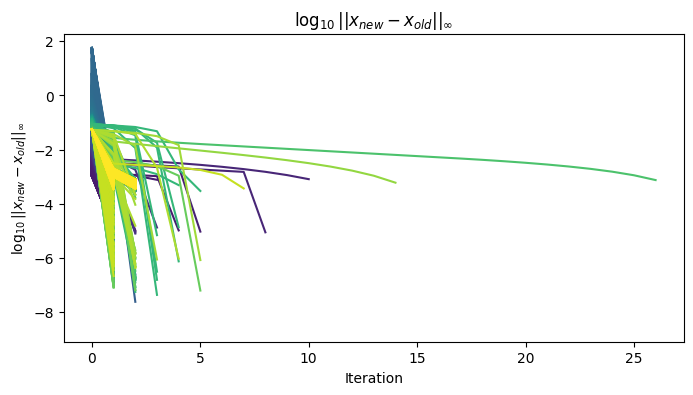

In [13]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in convergence_queues:
    if convergence_queues[key]:
        ax.plot(np.log10(np.vstack(convergence_queues[key])).max(axis=1))
_ = plt.title('$\log_{10} ||x_{new} - x_{old}||_\infty$')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\log_{10} ||x_{new} - x_{old}||_\infty$')

### Error convergence criterion $||f(x)||_\infty$

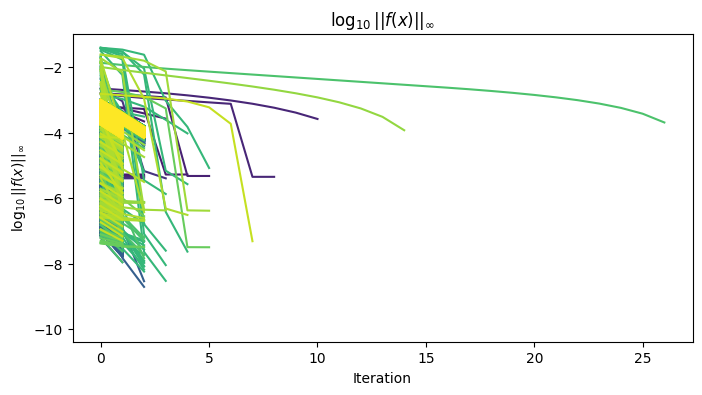

In [14]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in error_queues:
    ax.plot(np.log10(np.array(error_queues[key])))
_ = plt.title('$\log_{10} ||f(x)||_\infty$')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\log_{10} ||f(x)||_\infty$')


#### Newton decrement $\nabla f(x)^T \Delta x$

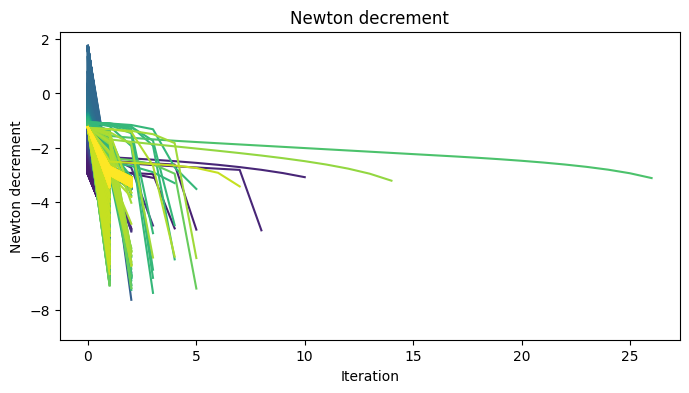

In [15]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in decrement_queues:
    ax.plot(np.log10(np.array(decrement_queues[key])))
_ = plt.title('Newton decrement')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('Newton decrement')

### Newton step size

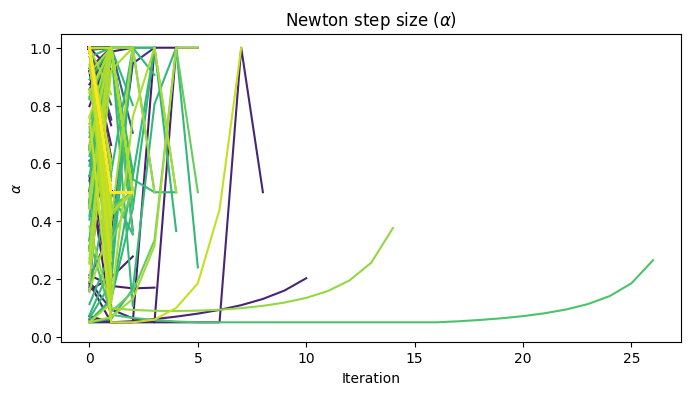

In [16]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in learning_queues:
    ax.plot(np.array(learning_queues[key]))
_ = plt.title('Newton step size ($\\alpha$)')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\\alpha$')


### Number of iterations elapsed

Text(0, 0.5, 'Iterations')

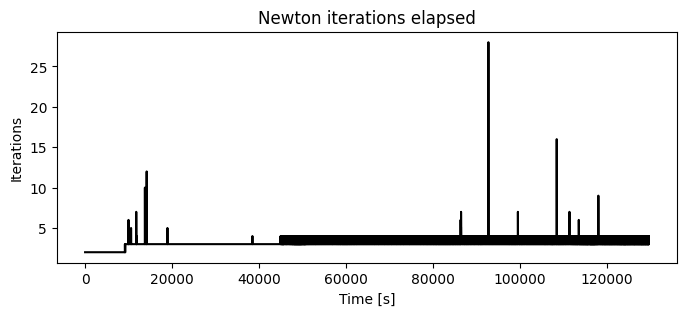

In [17]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(iterations_elapsed).plot(ax=ax, c='k')
plt.title('Newton iterations elapsed')
plt.xlabel('Time [s]')
plt.ylabel('Iterations')

### Simulation time elapsed

Text(0, 0.5, 'Clock time elapsed [s]')

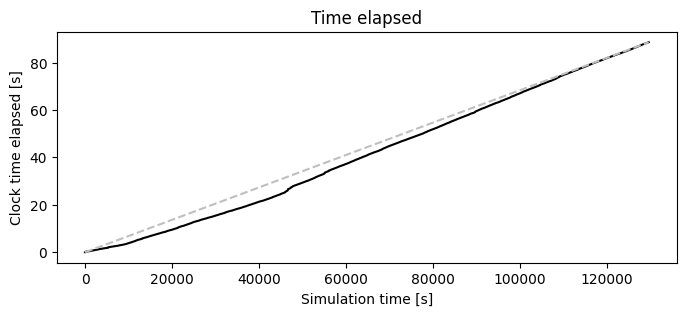

In [18]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(step_time_taken).cumsum().plot(ax=ax, c='k')
plt.plot([0, simulation.t], [0, pd.Series(step_time_taken).cumsum().iloc[-1]], c='0.75', linestyle='--')
plt.title('Time elapsed')
plt.xlabel('Simulation time [s]')
plt.ylabel('Clock time elapsed [s]')